# Benchmarking [![Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/maxencefaldor/bbobax/blob/main/notebooks/03_benchmarking.ipynb)

In this notebook, we compare six evolution strategies across the full bbob suite, the way COCO compares them.

A suite's whole value is that it does *not* force an aggregation: results are read per function, so no arbitrary weighting over function families ever enters. When one summary curve is wanted anyway, COCO's instrument is the **ECDF over target precisions** -- bounded, scale-free, and anytime -- rather than a mean of raw fitnesses, which the suite's $10^{16}$ spread of value ranges would render meaningless.

Three choices below do quiet statistical work:

- **Every algorithm sees the same instances.** The instance keys are drawn once and reused, so comparisons are paired.
- **All 24 functions run**, at one dimension, with instances vmapped inside one compiled program per (algorithm, function).
- **Everything is stored per (algorithm, function, instance)** -- the aggregate curve, the per-function reading, and any re-weighting are computations over the record, not new runs.

## Install

You will need Python 3.11 or later, and a working JAX installation. For example, you can install JAX with:

In [ ]:
%pip install -U "jax[cuda]"

Then, install bbobax from PyPi:

In [ ]:
%pip install -U "bbobax[notebooks]"

## Import

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
from evosax.algorithms import algorithms

import bbobax

## The experiment

The full suite at $D = 10$, eight instances per function, a fixed budget for everyone. The six algorithms span evosax's families, all at their published defaults -- this is a benchmark of defaults, not of tuning.

In [2]:
num_dims = 10
num_generations = 512
population_size = 128
num_instances = 8

problems = bbobax.bbob_suite(num_dims=num_dims)

es_classes = {
    "SimpleES": {},
    "PGPE": {},
    "Open_ES": {"optimizer": optax.adam(1e-3)},
    "SNES": {},
    "Sep_CMA_ES": {},
    "CMA_ES": {},
}

## The inner loop

The same runner as [02_bbo](02_bbo.ipynb), returning the best-so-far precision after every generation -- the full trajectory, because the ECDF needs to know *when* each target was reached, not only whether. Instances are vmapped; each (algorithm, function) pair is one compiled program, with the function statically known so there is no dispatch.

In [3]:
def make_run(problem, es, es_params):
    """Build the compiled per-instance runner for one (algorithm, function)."""

    def run(key):
        key_instance, key_mean, key_init, key_run = jax.random.split(key, 4)
        params = problem.sample(key_instance)
        state = es.init(key_init, problem.sample_x(key_mean), es_params)

        def step(state, key):
            key_ask, key_eval, key_tell = jax.random.split(key, 3)
            population, state = es.ask(key_ask, state, es_params)
            keys = jax.random.split(key_eval, population_size)
            fitness = jax.vmap(problem.evaluate, in_axes=(0, 0, None))(
                keys, population, params
            ).fitness
            state, _ = es.tell(key_tell, population, fitness, state, es_params)
            return state, jnp.min(fitness)

        _, best = jax.lax.scan(step, state, jax.random.split(key_run, num_generations))
        # At this budget an algorithm can converge completely and underflow to
        # NaN; such generations stop contributing rather than poisoning the
        # best-so-far (an ECDF of best-so-far values is monotone -- if a curve
        # ever dips, this is the line that was missing).
        best = jnp.where(jnp.isnan(best), jnp.inf, best)
        return jax.lax.cummin(best) - params.f_opt

    return jax.jit(jax.vmap(run))

## Run

In [4]:
key = jax.random.key(0)

# Drawn once, reused for every algorithm: paired comparisons.
key, subkey = jax.random.split(key)
instance_keys = dict(
    zip(problems, jax.random.split(subkey, (len(problems), num_instances)))
)

# A dummy solution, only for shapes: every problem shares the dimension.
solution = jnp.zeros(num_dims)

trajectories = []
for es_name, es_kwargs in es_classes.items():
    print(f"Running {es_name}...")
    es = algorithms[es_name](
        population_size=population_size, solution=solution, **es_kwargs
    )
    trajectories.append(
        np.stack(
            [
                np.asarray(
                    make_run(problem, es, es.default_params)(instance_keys[name])
                )
                for name, problem in problems.items()
            ]
        )
    )

# (algorithm, function, instance, generation) best-so-far precisions: the record.
trajectories = np.stack(trajectories)
trajectories.shape

Running SimpleES...


Running PGPE...


Running Open_ES...


Running SNES...


Running Sep_CMA_ES...


Running CMA_ES...


(6, 24, 8, 512)

## The aggregate reading: ECDF over targets

The targets are cocopp's `pprldmany_target_values`: the 51 values $10^2, 10^{1.8}, \ldots, 10^{-8}$, the grid behind every published BBOB runtime-distribution plot. A point on a curve reads: after this many evaluations, this fraction of (function, instance, target) triples has been solved. The aggregation weights every function equally -- that *is* a choice, and it is the community's.

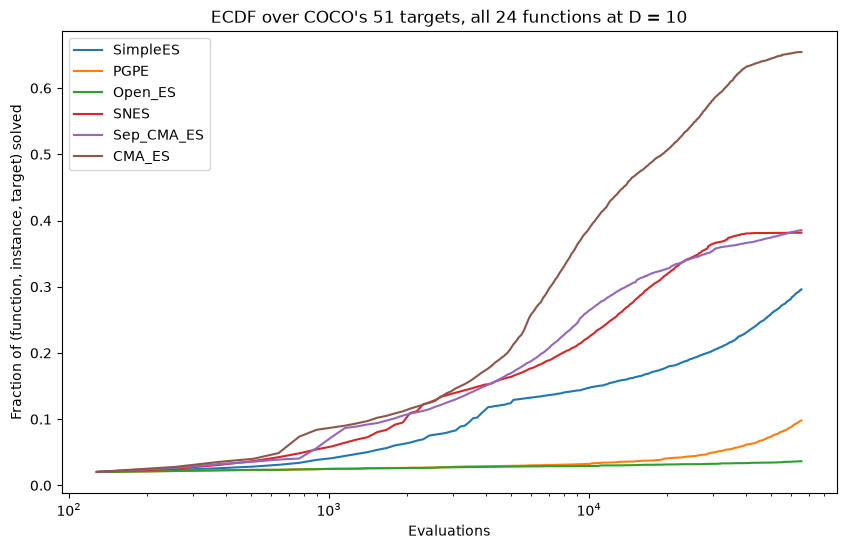

In [5]:
targets = 10.0 ** np.arange(2, -8.2, -0.2)  # cocopp's pprldmany_target_values

# solved[..., generation, target]: has this trajectory reached this target yet?
solved = trajectories[..., None] <= targets
evaluations = (np.arange(num_generations) + 1) * population_size

plt.figure(figsize=(10, 6))
for es_name, es_solved in zip(es_classes, solved):
    plt.plot(evaluations, es_solved.mean(axis=(0, 1, 3)), label=es_name)
plt.xscale("log")
plt.xlabel("Evaluations")
plt.ylabel("Fraction of (function, instance, target) solved")
plt.title(f"ECDF over COCO's 51 targets, all 24 functions at D = {num_dims}")
plt.legend()
plt.show()

## The per-function reading

Where the aggregate came from -- each cell is the fraction of (instance, target) pairs an algorithm solved on one function at full budget. This is the reading the suite exists for: "strong on the unimodal ill-conditioned group, weak on weak-structure multimodal" is a sentence only this view can support.

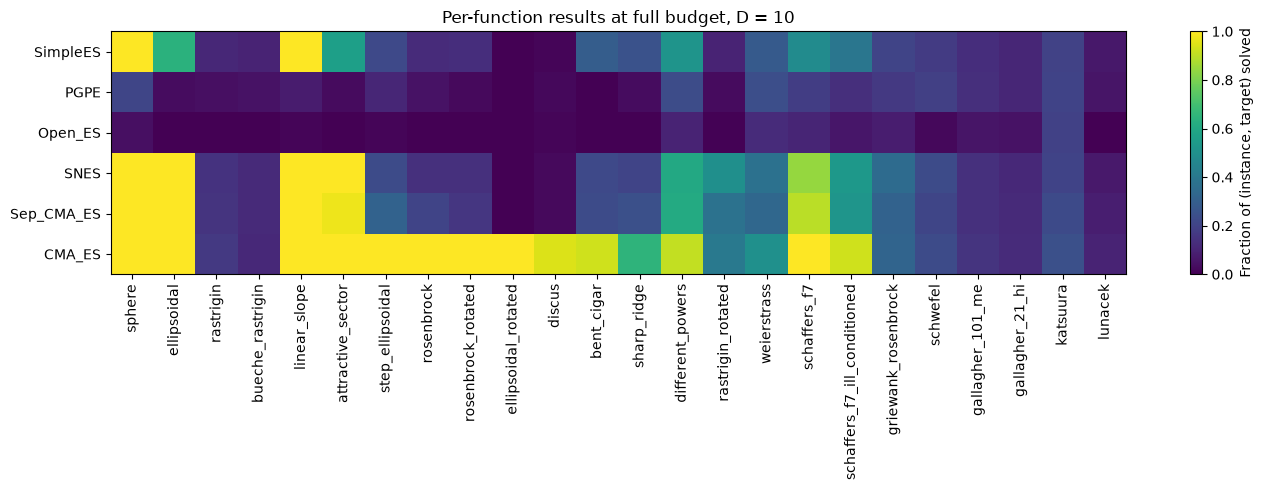

In [6]:
final = solved[..., -1, :].mean(axis=(2, 3))  # (algorithm, function)

fig, ax = plt.subplots(figsize=(14, 5))
image = ax.imshow(final, cmap="viridis", aspect="auto", vmin=0.0, vmax=1.0)
ax.set_xticks(range(len(problems)), problems, rotation=90)
ax.set_yticks(range(len(es_classes)), es_classes)
fig.colorbar(image, label="Fraction of (instance, target) solved")
ax.set_title(f"Per-function results at full budget, D = {num_dims}")
plt.tight_layout()
plt.show()

## Next

- [04_meta_bbo](04_meta_bbo.ipynb) -- when comparing hand-designed algorithms is not enough: meta-learning a component over the suite, where an aggregation can no longer be avoided and has to be designed.